<a href="https://colab.research.google.com/github/penajuanmanuel6-hub/automated-etl-pipeline/blob/main/simulacro_nitrogeno_lnv.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

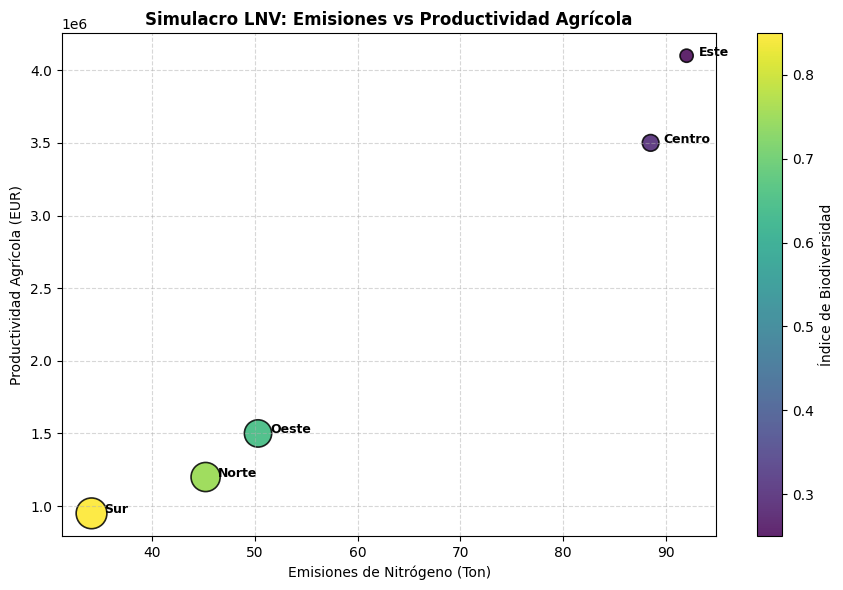

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Ingesta y Limpieza de Datos (ETL)
data = {
    'Region': ['Norte', 'Centro', 'Sur', 'Este', 'Oeste'],
    'Nitrogeno_Emision_Ton': [45.2, 88.5, 34.1, 92.0, 50.3],
    'Productividad_Agricola_EUR': [1200000, 3500000, 950000, 4100000, 1500000],
    'Indice_Biodiversidad': [0.75, 0.30, 0.85, 0.25, 0.65]
}

df = pd.DataFrame(data)
df['Emision_Normalizada'] = df['Nitrogeno_Emision_Ton'] / df['Nitrogeno_Emision_Ton'].max()

# 2. Modelación Cuantitativa y Sostenibilidad
def calcular_indice_sostenibilidad(row):
    peso_ecologico = row['Indice_Biodiversidad']
    peso_economico = 1 - (row['Productividad_Agrícola_EUR'] / df['Productividad_Agricola_EUR'].max()) if 'Productividad_Agrícola_EUR' in row else 1 - (row['Productividad_Agricola_EUR'] / df['Productividad_Agricola_EUR'].max())
    return round((peso_ecologico * 0.6) + (peso_economico * 0.4), 3)

df['Indice_Sostenibilidad'] = df.apply(calcular_indice_sostenibilidad, axis=1)

# 3. Visualización Estática (Compatible con GitHub)
fig, ax = plt.subplots(figsize=(9, 6))

scatter = ax.scatter(
    df['Nitrogeno_Emision_Ton'],
    df['Productividad_Agricola_EUR'],
    s=df['Indice_Sostenibilidad'] * 600, # Tamaño de burbuja según sostenibilidad
    c=df['Indice_Biodiversidad'],        # Color según biodiversidad
    cmap='viridis',
    alpha=0.85,
    edgecolors='black',
    linewidth=1.2
)

ax.set_title('Simulacro LNV: Emisiones vs Productividad Agrícola', fontsize=12, fontweight='bold')
ax.set_xlabel('Emisiones de Nitrógeno (Ton)', fontsize=10)
ax.set_ylabel('Productividad Agrícola (EUR)', fontsize=10)

# Barra de color para el índice de biodiversidad
cbar = plt.colorbar(scatter)
cbar.set_label('Índice de Biodiversidad', fontsize=10)

# Etiquetas de las regiones en cada punto
for i, txt in enumerate(df['Region']):
    ax.annotate(txt, (df['Nitrogeno_Emision_Ton'][i] + 1.2, df['Productividad_Agricola_EUR'][i]), fontsize=9, fontweight='semibold')

plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()